In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import json
import pandas as pd
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")
plt.rcParams.update(
    {
        "figure.figsize": (14, 8),
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "font.family": ["Hiragino Sans", "sans-serif"],
    }
)

# Load data
with open("../songs_db.json") as f:
    db = json.load(f)

# Build plays DataFrame
rows = []
for ts, song in db["songs_dic"].items():
    dj = db["dj_dic"].get(ts)
    parts = song.split(" - ", 1)
    artist = parts[0].strip() if len(parts) == 2 else "Unknown"
    title = parts[1].strip() if len(parts) == 2 else song.strip()
    rows.append((ts, song, artist, title, dj))

plays = pd.DataFrame(rows, columns=["timestamp", "song", "artist", "title", "dj"])
plays["timestamp"] = pd.to_datetime(plays["timestamp"], utc=True)
plays["year"] = plays["timestamp"].dt.year
plays["month"] = plays["timestamp"].dt.month
plays["hour"] = plays["timestamp"].dt.hour
plays["dow"] = plays["timestamp"].dt.dayofweek  # 0=Mon
plays = plays.sort_values("timestamp").reset_index(drop=True)

# Filter out junk
JUNK = {"Unknown", "Unknown artist", "", "Live mix by AfterGlow"}
plays_clean = plays[~plays["artist"].isin(JUNK) & (plays["song"].str.len() > 0)].copy()

n_plays = len(plays_clean)
n_songs = plays_clean["song"].nunique()
n_artists = plays_clean["artist"].nunique()
yr_min = plays_clean["year"].min()
yr_max = plays_clean["year"].max()

print(
    f"{n_plays:,} plays  ·  {n_songs:,} unique songs  ·  {n_artists:,} artists  ·  {yr_min}–{yr_max}"
)

1,713,665 plays  ·  145,134 unique songs  ·  44,053 artists  ·  2011–2026


# 44,000 Songs

_archaeology of r/a/dio (2011–2026)_

---

## 1. The Long Tail — Power Law of Plays

_Does 20% of the library account for 80% of airtime? Or is this a true long-tail station?_


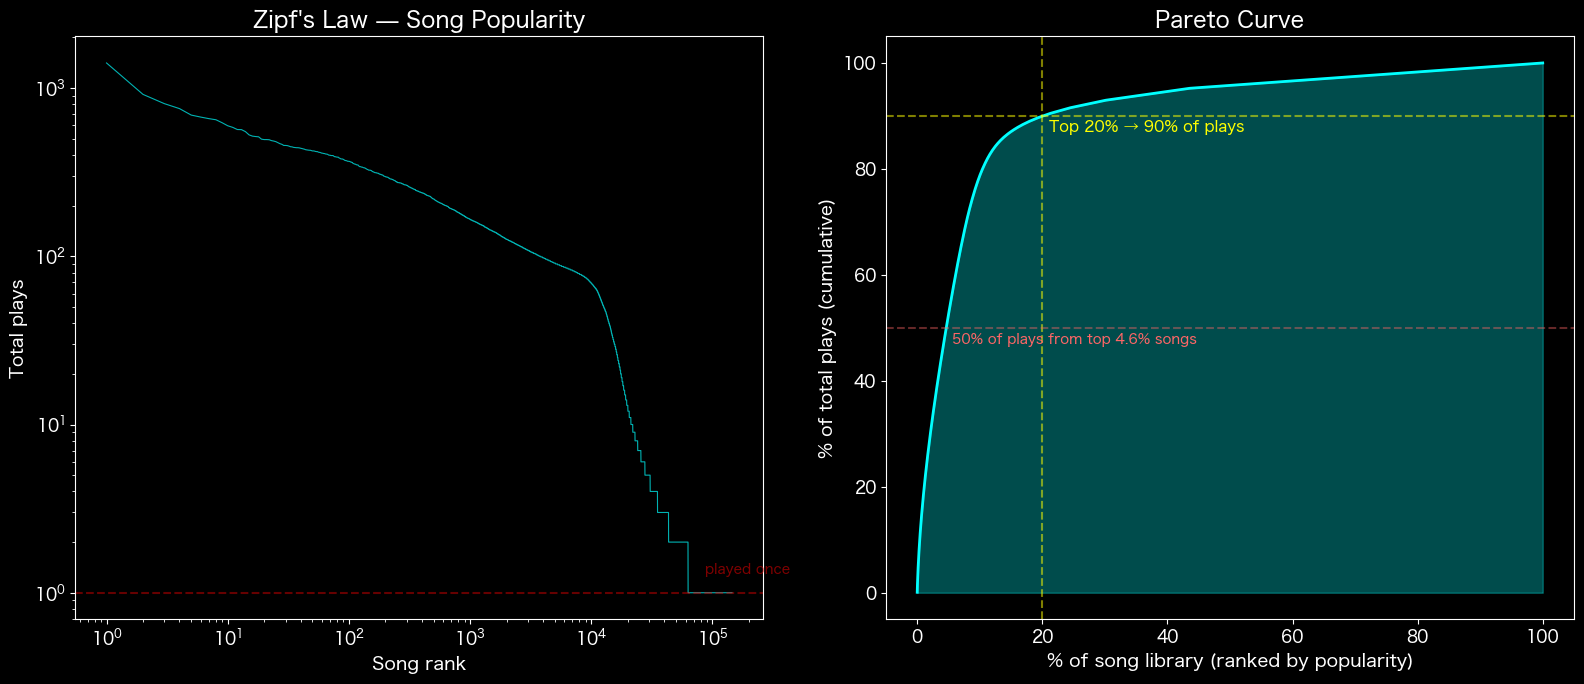


Distribution:
  Played exactly once:  82,258 songs (57%)
  Played ≤5 times:      117,440 songs (81%)
  Played 100+ times:    3,835 songs
  Played 1,000+ times:  1 songs

The top 10 most-played songs:
  1,410×  FLOW - COLORS
    917×  Supercell - Feel so good
    808×  #comiket - trainroll
    755×  Nothing's Carved in Stone - Out of Control
    691×  MAN WITH A MISSION - Raise your flag
    672×  Seira Kagami - Super Special 
    658×  Abingdon Boys School - Howling
    648×  Carlito - GO! GO! CARLITO!
    622×  Kaneda Tomoko - Ganbara
    597×  アフィリア・サーガ - ネプチューヌ☆サガして


In [3]:
# Play count per song
song_counts = (
    plays_clean.groupby("song")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="plays")
)
song_counts["rank"] = range(1, len(song_counts) + 1)
song_counts["cum_plays"] = song_counts["plays"].cumsum()
song_counts["cum_pct"] = song_counts["cum_plays"] / song_counts["plays"].sum() * 100
song_counts["rank_pct"] = song_counts["rank"] / len(song_counts) * 100

# Pareto analysis
pct_20 = song_counts[song_counts["rank_pct"] <= 20]["cum_pct"].iloc[-1]
pct_50 = song_counts[song_counts["cum_pct"] <= 50].iloc[-1]
pct_80 = song_counts[song_counts["cum_pct"] <= 80].iloc[-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: rank vs plays (log-log)
ax1.plot(
    song_counts["rank"], song_counts["plays"], color="cyan", alpha=0.7, linewidth=0.8
)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Song rank")
ax1.set_ylabel("Total plays")
ax1.set_title("Zipf's Law — Song Popularity")
ax1.axhline(y=1, color="red", linestyle="--", alpha=0.4)
ax1.text(
    len(song_counts) * 0.6, 1.3, "played once", color="red", alpha=0.5, fontsize=10
)

# Right: cumulative Pareto
ax2.fill_between(
    song_counts["rank_pct"], song_counts["cum_pct"], alpha=0.3, color="cyan"
)
ax2.plot(song_counts["rank_pct"], song_counts["cum_pct"], color="cyan", linewidth=2)
ax2.axvline(x=20, color="yellow", linestyle="--", alpha=0.5)
ax2.axhline(y=pct_20, color="yellow", linestyle="--", alpha=0.5)
ax2.text(
    21, pct_20 - 3, f"Top 20% → {pct_20:.0f}% of plays", color="yellow", fontsize=11
)
ax2.axhline(y=50, color="#ff6666", linestyle="--", alpha=0.4)
ax2.text(
    pct_50["rank_pct"] + 1,
    47,
    f"50% of plays from top {pct_50['rank_pct']:.1f}% songs",
    color="#ff6666",
    fontsize=10,
)
ax2.set_xlabel("% of song library (ranked by popularity)")
ax2.set_ylabel("% of total plays (cumulative)")
ax2.set_title("Pareto Curve")

plt.tight_layout()
plt.show()

# Stats
one_plays = (song_counts["plays"] == 1).sum()
five_or_less = (song_counts["plays"] <= 5).sum()
hundred_plus = (song_counts["plays"] >= 100).sum()
thousand_plus = (song_counts["plays"] >= 1000).sum()

print(f"\nDistribution:")
print(f"  Played exactly once:  {one_plays:,} songs ({one_plays / n_songs:.0%})")
print(f"  Played ≤5 times:      {five_or_less:,} songs ({five_or_less / n_songs:.0%})")
print(f"  Played 100+ times:    {hundred_plus:,} songs")
print(f"  Played 1,000+ times:  {thousand_plus:,} songs")
print(f"\nThe top 10 most-played songs:")
for _, r in song_counts.head(10).iterrows():
    print(f"  {r['plays']:5,}×  {r['song'][:75]}")

---
## 2. Half-Life of a Hit
_Cohort survival curves by debut year._

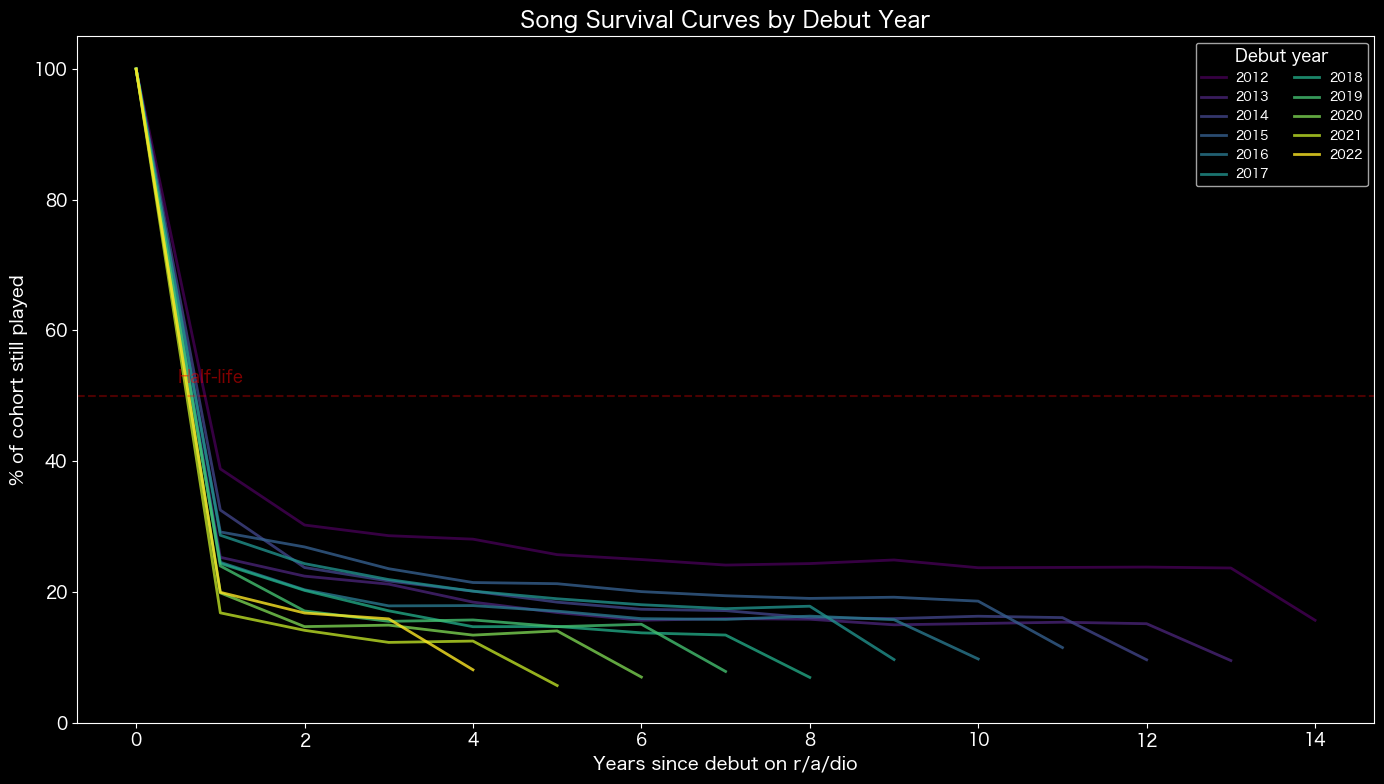

Song half-life by debut year (years until <50% still played):
  2012: 1.0 years  (21,096.0 songs in cohort)
  2013: 1.0 years  (16,798.0 songs in cohort)
  2014: 1.0 years  (8,545.0 songs in cohort)
  2015: 1.0 years  (9,334.0 songs in cohort)
  2016: 1.0 years  (6,820.0 songs in cohort)
  2017: 1.0 years  (7,462.0 songs in cohort)
  2018: 1.0 years  (7,775.0 songs in cohort)
  2019: 1.0 years  (7,118.0 songs in cohort)
  2020: 1.0 years  (10,551.0 songs in cohort)
  2021: 1.0 years  (10,775.0 songs in cohort)
  2022: 1.0 years  (6,792.0 songs in cohort)


In [4]:
# Per-song: first play, last play, years active
song_life = (
    plays_clean.groupby("song")
    .agg(
        first_play=("timestamp", "min"),
        last_play=("timestamp", "max"),
        total_plays=("timestamp", "count"),
        n_years=("year", "nunique"),
        years_list=("year", lambda x: sorted(x.unique())),
        artist=("artist", "first"),
    )
    .reset_index()
)

song_life["debut_year"] = song_life["first_play"].dt.year
song_life["lifespan_days"] = (song_life["last_play"] - song_life["first_play"]).dt.days
song_life["lifespan_years"] = song_life["lifespan_days"] / 365.25

# Survival analysis: for each cohort (debut year), what % of songs are still
# being played N years later?
# "Still played" = appeared at least once in year (debut_year + N)
max_year = plays_clean["year"].max()

cohorts = range(2012, 2023)  # cohorts with enough follow-up time
survival_data = []

for cohort_yr in cohorts:
    cohort_songs = song_life[song_life["debut_year"] == cohort_yr]
    n_total = len(cohort_songs)
    if n_total < 50:
        continue
    for delta in range(0, max_year - cohort_yr + 1):
        check_year = cohort_yr + delta
        # How many songs from this cohort were played in check_year?
        alive = cohort_songs["years_list"].apply(lambda yrs: check_year in yrs).sum()
        survival_data.append(
            {
                "cohort": cohort_yr,
                "years_since_debut": delta,
                "pct_alive": alive / n_total * 100,
                "n_alive": alive,
                "n_total": n_total,
            }
        )

surv = pd.DataFrame(survival_data)

fig, ax = plt.subplots(figsize=(14, 8))
cmap = plt.cm.viridis
cohort_list = sorted(surv["cohort"].unique())
colors = {c: cmap(i / max(len(cohort_list) - 1, 1)) for i, c in enumerate(cohort_list)}

for cohort_yr in cohort_list:
    d = surv[surv["cohort"] == cohort_yr]
    ax.plot(
        d["years_since_debut"],
        d["pct_alive"],
        color=colors[cohort_yr],
        linewidth=2,
        alpha=0.8,
        label=str(cohort_yr),
    )

ax.set_xlabel("Years since debut on r/a/dio")
ax.set_ylabel("% of cohort still played")
ax.set_title("Song Survival Curves by Debut Year")
ax.legend(title="Debut year", ncol=2, fontsize=9)
ax.set_ylim(0, 105)
ax.axhline(y=50, color="red", linestyle="--", alpha=0.3)
ax.text(0.5, 52, "Half-life", color="red", alpha=0.5)
plt.tight_layout()
plt.show()

# Half-life per cohort
print("Song half-life by debut year (years until <50% still played):")
for c in cohort_list:
    d = surv[(surv["cohort"] == c) & (surv["pct_alive"] < 50)]
    if len(d) > 0:
        hl = d.iloc[0]["years_since_debut"]
        n = surv[surv["cohort"] == c].iloc[0]["n_total"]
        print(f"  {c}: {hl} years  ({n:,} songs in cohort)")
    else:
        n = surv[surv["cohort"] == c].iloc[0]["n_total"]
        print(f"  {c}: >={max_year - c} years (still above 50%)  ({n:,} songs)")

---
## 3. Lifecycle Archetypes
_Clustering songs by their play-over-time shape._

17,545 songs with 20+ plays across 3+ years


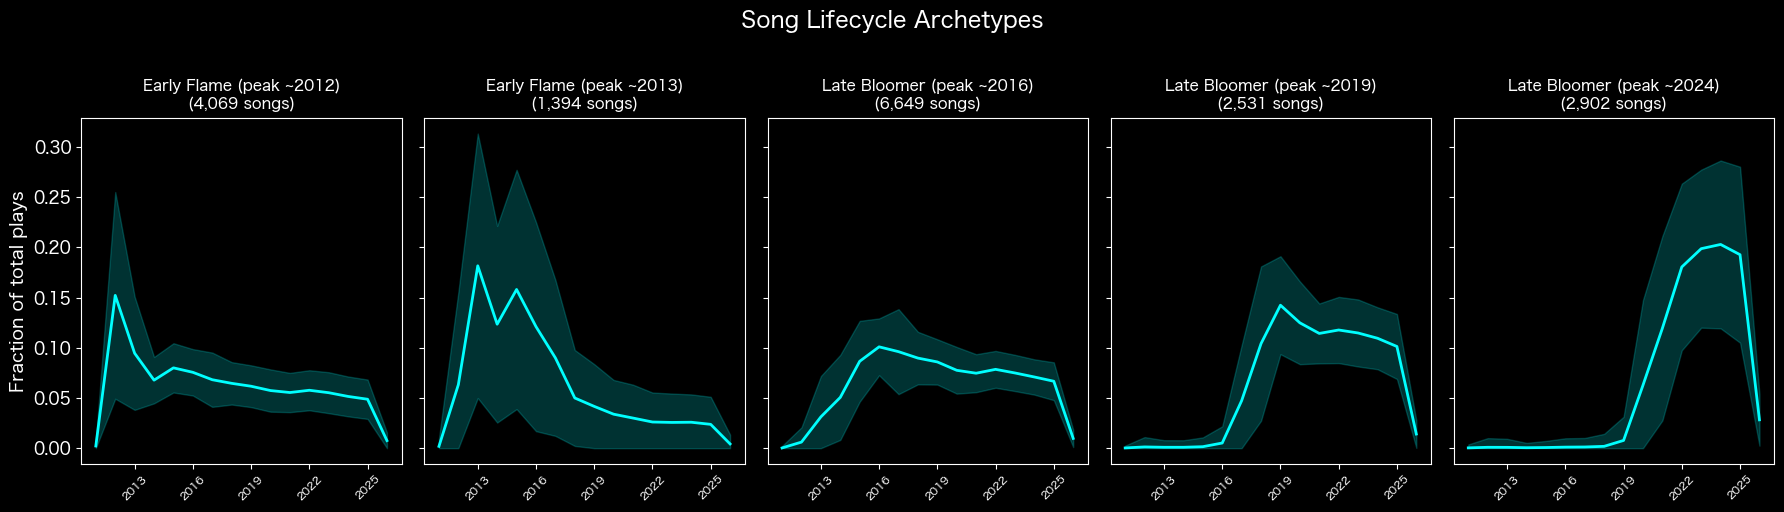

Example songs per archetype:

  Early Flame (peak ~2012) (4069 songs):
    1,410×  FLOW - COLORS
      917×  Supercell - Feel so good
      808×  #comiket - trainroll

  Early Flame (peak ~2013) (1394 songs):
      397×  coda - BLOODY STREAM
      342×  Max Coveri - Running in the 90's
      337×  ランコ - Clockup Flowers

  Late Bloomer (peak ~2016) (6649 songs):
      755×  Nothing's Carved in Stone - Out of Control
      691×  MAN WITH A MISSION - Raise your flag
      622×  Kaneda Tomoko - Ganbara

  Late Bloomer (peak ~2019) (2531 songs):
      338×  Junko Ohashi - Telephone Number
      292×  ZAQ - Serendipity
      288×  MAN WITH A MISSION - My Hero

  Late Bloomer (peak ~2024) (2902 songs):
      281×  The Protomen - The Hounds
      273×  Creepy Nuts - Yofukashino Uta
      234×  Casey Edwards, Victor Borba - Bury the Light


In [5]:
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist

# Build year-by-year play profile for songs with enough history
# Only songs with 20+ total plays and active across 3+ years
eligible = song_life[
    (song_life["total_plays"] >= 20) & (song_life["n_years"] >= 3)
].copy()
print(f"{len(eligible):,} songs with 20+ plays across 3+ years")

# Yearly play counts per song
yearly = (
    plays_clean[plays_clean["song"].isin(eligible["song"])]
    .groupby(["song", "year"])
    .size()
    .reset_index(name="plays")
)
yearly_pivot = yearly.pivot_table(
    index="song", columns="year", values="plays", fill_value=0
)

# Normalize each song's profile to sum=1 (relative shape, not magnitude)
profiles = yearly_pivot.div(yearly_pivot.sum(axis=1), axis=0)

# Cluster the profiles
dist = pdist(profiles.values, metric="cosine")
Z = linkage(dist, method="ward")
n_clusters = 5
labels = fcluster(Z, n_clusters, criterion="maxclust")
profiles["cluster"] = labels

# Name clusters by their peak timing
cluster_peaks = profiles.groupby("cluster")[list(yearly_pivot.columns)].mean()
cluster_peak_year = cluster_peaks.idxmax(axis=1)
cluster_sizes = profiles["cluster"].value_counts().sort_index()

# Sort clusters by peak year for consistent ordering
cluster_order = cluster_peak_year.sort_values().index.tolist()

# Assign descriptive names based on shape
cluster_names = {}
for i, cl in enumerate(cluster_order):
    peak = cluster_peak_year[cl]
    mean_profile = cluster_peaks.loc[cl]
    # Check if it's flat (low variance = evergreen)
    cv = mean_profile.std() / mean_profile.mean()
    last_3 = mean_profile.iloc[-3:].mean()
    first_3 = mean_profile.iloc[:3].mean()
    if cv < 0.4:
        cluster_names[cl] = f"Evergreen (peak ~{peak})"
    elif last_3 > first_3 * 1.5:
        cluster_names[cl] = f"Late Bloomer (peak ~{peak})"
    elif first_3 > last_3 * 2:
        cluster_names[cl] = f"Early Flame (peak ~{peak})"
    else:
        cluster_names[cl] = f"Era {peak} Peak"

fig, axes = plt.subplots(1, n_clusters, figsize=(18, 5), sharey=True)
years = list(yearly_pivot.columns)

for ax_i, cl in enumerate(cluster_order):
    ax = axes[ax_i]
    members = profiles[profiles["cluster"] == cl].drop(columns="cluster")
    mean_profile = members.mean()
    std_profile = members.std()

    ax.fill_between(
        years,
        (mean_profile - std_profile).clip(0),
        mean_profile + std_profile,
        alpha=0.2,
        color="cyan",
    )
    ax.plot(years, mean_profile, color="cyan", linewidth=2)
    ax.set_title(f"{cluster_names[cl]}\n({cluster_sizes[cl]:,} songs)", fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    # Show every 3rd year
    ax.set_xticks([y for y in years if y % 3 == 0])

axes[0].set_ylabel("Fraction of total plays")
fig.suptitle("Song Lifecycle Archetypes", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Example songs from each cluster
print("Example songs per archetype:")
eligible_with_cl = eligible.merge(profiles[["cluster"]].reset_index(), on="song")
for cl in cluster_order:
    members = eligible_with_cl[eligible_with_cl["cluster"] == cl].sort_values(
        "total_plays", ascending=False
    )
    print(f"\n  {cluster_names[cl]} ({len(members)} songs):")
    for _, r in members.head(3).iterrows():
        print(f"    {r['total_plays']:5,}×  {r['song'][:70]}")

---

## 4. Zombies & Ghosts

_Songs that came back from the dead, and former giants now silent._


In [6]:
# Zombies: songs with a gap of 3+ years between plays that then returned
def find_zombies(song_plays_df, min_gap_years=3):
    """Find songs with long dormancy periods followed by revival."""
    results = []
    for song, group in song_plays_df.groupby('song'):
        years_active = sorted(group['year'].unique())
        if len(years_active) < 2:
            continue
        max_gap = 0
        gap_start = None
        for i in range(1, len(years_active)):
            gap = years_active[i] - years_active[i-1]
            if gap > max_gap:
                max_gap = gap
                gap_start = years_active[i-1]
                gap_end = years_active[i]
        if max_gap >= min_gap_years:
            plays_before = group[group['year'] <= gap_start].shape[0]
            plays_after = group[group['year'] >= gap_end].shape[0]
            results.append({
                'song': song,
                'gap_years': max_gap,
                'dormant_from': gap_start,
                'revived_in': gap_end,
                'plays_before': plays_before,
                'plays_after': plays_after,
                'total_plays': len(group),
            })
    return pd.DataFrame(results)

zombies = find_zombies(plays_clean)
zombies = zombies.sort_values('plays_after', ascending=False)

print(f'ZOMBIES — {len(zombies):,} songs returned after 3+ years of silence\n')
print('Most successful comebacks (by post-revival plays):')
for _, r in zombies.head(15).iterrows():
    print(f'  {r["song"][:60]:60s}  silent {r["dormant_from"]}→{r["revived_in"]} ({r["gap_years"]}yr gap)  '
          f'{r["plays_before"]}→{r["plays_after"]} plays')

# Ghosts: songs with 200+ all-time plays, not played since 2023
ghosts = song_life[(song_life['total_plays'] >= 200) & (song_life['last_play'].dt.year < 2023)]
ghosts = ghosts.sort_values('total_plays', ascending=False)

print(f'\n\nGHOSTS — {len(ghosts)} songs with 200+ plays, silent since 2023\n')
for _, r in ghosts.head(15).iterrows():
    last_yr = r['last_play'].year
    print(f'  {r["total_plays"]:5,}×  last heard {last_yr}  {r["song"][:65]}')

# One-play wonders — normalized by total songs played per DJ
one_plays_df = song_life[song_life['total_plays'] == 1].copy()
one_plays_df = one_plays_df.merge(
    plays_clean[plays_clean['song'].isin(one_plays_df['song'])][['song', 'dj']].drop_duplicates(),
    on='song', how='left'
)
one_plays_known = one_plays_df[one_plays_df['dj'].notna() & (one_plays_df['dj'] != 'Unknown')].copy()
print(f'\n\nONE-PLAY WONDERS — {len(one_plays_df):,} songs played exactly once')

# Normalize: one-play songs as % of total unique songs that DJ played
dj_total_unique = plays_clean[plays_clean['dj'].notna()].groupby('dj')['song'].nunique().rename('total_unique')
opw_by_dj = one_plays_known.groupby('dj').size().rename('one_plays')
opw_norm = pd.concat([opw_by_dj, dj_total_unique], axis=1).dropna()
opw_norm['one_play_pct'] = opw_norm['one_plays'] / opw_norm['total_unique'] * 100
# Filter to DJs with at least 500 unique songs (meaningful sample)
opw_norm = opw_norm[opw_norm['total_unique'] >= 500].sort_values('one_play_pct', ascending=False)

print(f'\nDJs with highest one-play rate (min 500 unique songs):')
for dj, r in opw_norm.head(12).iterrows():
    print(f'  {str(dj):20s} {r["one_play_pct"]:5.1f}% one-plays  ({r["one_plays"]:.0f}/{r["total_unique"]:.0f} unique songs)')

ZOMBIES — 12,947 songs returned after 3+ years of silence

Most successful comebacks (by post-revival plays):
  Anonymous - /jp/ Themesong 2                                  silent 2012→2015 (3yr gap)  1→178 plays
  Nathalie - Heartbeat                                          silent 2012→2015 (3yr gap)  2→162 plays
  Maaya Sakamoto - Platinum                                     silent 2014→2017 (3yr gap)  64→144 plays
  Horie Yui - sugar sweet nightmare                             silent 2011→2014 (3yr gap)  1→140 plays
  Caramell - Caramelldansen (Speedycake Remix)                  silent 2011→2016 (5yr gap)  1→137 plays
  Long Shot Party - Distance                                    silent 2012→2017 (5yr gap)  2→126 plays
  Ritsuko Okazaki - Morning Grace                               silent 2011→2017 (6yr gap)  1→100 plays
  Go 2 - Looka Bomba                                            silent 2012→2015 (3yr gap)  1→91 plays
  LiSA - THIS ILLUSION                                    



ONE-PLAY WONDERS — 82,258 songs played exactly once



DJs with highest one-play rate (min 500 unique songs):
  apt-get               75.9% one-plays  (5961/7852 unique songs)
  Sachiko's 2AM POWERHOUSE  59.6% one-plays  (474/795 unique songs)
  Chrono                58.3% one-plays  (646/1109 unique songs)
  Wessie                58.0% one-plays  (314/541 unique songs)
  HIACE                 57.7% one-plays  (1512/2619 unique songs)
  suedoe                53.2% one-plays  (612/1150 unique songs)
  Kralled               47.7% one-plays  (11167/23401 unique songs)
  McDoogle              47.4% one-plays  (4199/8854 unique songs)
  ed                    45.9% one-plays  (6631/14436 unique songs)
  n0n0chi               43.9% one-plays  (1175/2676 unique songs)
  Ekureiru              41.9% one-plays  (6495/15490 unique songs)
  sauce                 41.4% one-plays  (680/1643 unique songs)


---

## 5. The Vintage Heatmap

_When were songs born vs when are they played? Is the station living in the past?_


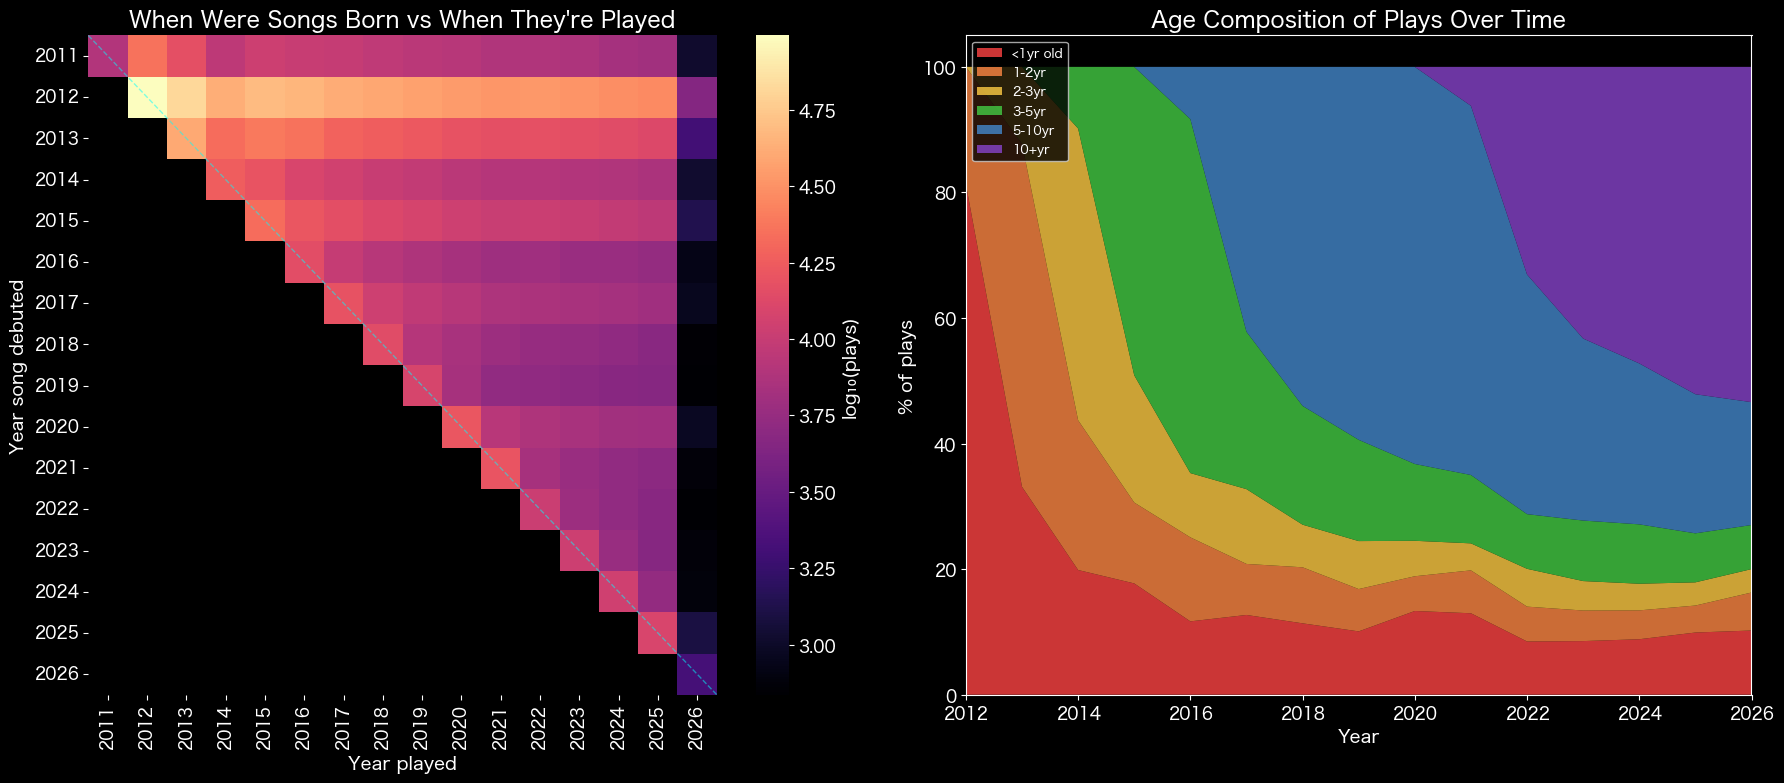

In 2026, the station's play-age breakdown:
  <1yr old      10.2%
  1-2yr          6.1%
  2-3yr          3.7%
  3-5yr          7.0%
  5-10yr        19.6%
  10+yr         53.4%


In [7]:
# For each play: debut year of the song vs year of the play
song_debut = song_life[["song", "debut_year"]].copy()
plays_vintage = plays_clean.merge(song_debut, on="song", how="left")

# Cross-tabulation: debut_year × play_year
vintage_ct = (
    plays_vintage.groupby(["debut_year", "year"]).size().reset_index(name="plays")
)
vintage_pivot = vintage_ct.pivot_table(
    index="debut_year", columns="year", values="plays", fill_value=0
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left: raw heatmap (log scale for visibility)
sns.heatmap(
    np.log10(vintage_pivot.replace(0, np.nan)),
    cmap="magma",
    ax=ax1,
    cbar_kws={"label": "log₁₀(plays)"},
)
ax1.set_xlabel("Year played")
ax1.set_ylabel("Year song debuted")
ax1.set_title("When Were Songs Born vs When They're Played")
ax1.plot(
    [0, len(vintage_pivot.columns)],
    [0, len(vintage_pivot.index)],
    color="cyan",
    linestyle="--",
    alpha=0.5,
    linewidth=1,
)

# Right: stacked area — age composition of plays over time
play_years = sorted(plays_vintage["year"].unique())
age_bins = [0, 1, 2, 3, 5, 10, 99]
age_labels = ["<1yr old", "1-2yr", "2-3yr", "3-5yr", "5-10yr", "10+yr"]
age_colors = ["#ff4444", "#ff8844", "#ffcc44", "#44cc44", "#4488cc", "#8844cc"]

plays_vintage["song_age"] = plays_vintage["year"] - plays_vintage["debut_year"]
plays_vintage["age_bin"] = pd.cut(
    plays_vintage["song_age"], bins=age_bins, labels=age_labels, right=False
)

age_by_year = plays_vintage.groupby(["year", "age_bin"]).size().reset_index(name="n")
age_pivot = age_by_year.pivot_table(
    index="year", columns="age_bin", values="n", fill_value=0
)
age_pivot = age_pivot[[l for l in age_labels if l in age_pivot.columns]]
age_pct = age_pivot.div(age_pivot.sum(axis=1), axis=0) * 100

ax2.stackplot(
    age_pct.index,
    *[age_pct[col] for col in age_pct.columns],
    labels=age_pct.columns,
    colors=age_colors,
    alpha=0.8,
)
ax2.set_xlabel("Year")
ax2.set_ylabel("% of plays")
ax2.set_title("Age Composition of Plays Over Time")
ax2.legend(loc="upper left", fontsize=9)
ax2.set_xlim(2012, play_years[-1])

plt.tight_layout()
plt.show()

# Latest year stats
latest = age_pct.iloc[-1]
print(f"In {play_years[-1]}, the station's play-age breakdown:")
for label in age_labels:
    if label in latest.index:
        print(f"  {label:12s} {latest[label]:5.1f}%")

---
## 6. Artist Bump Chart

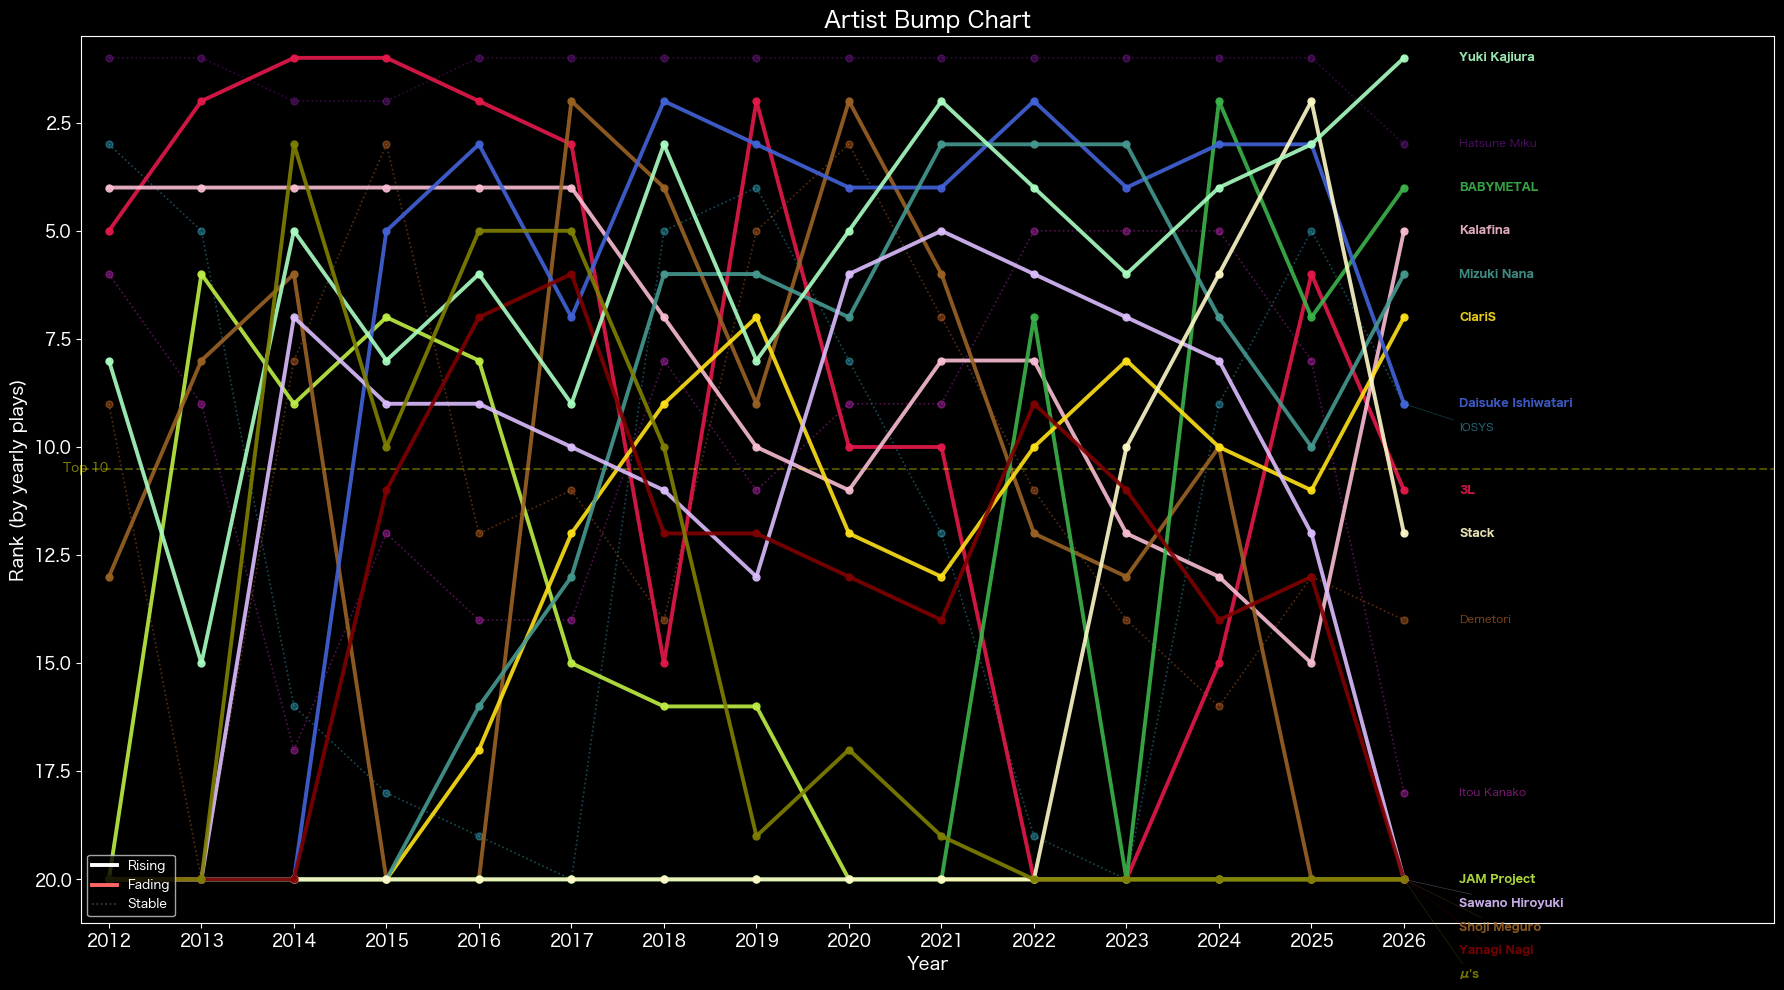

RISING:
  BABYMETAL                       #483 (2012) → #4 (2026)
  ClariS                          #53 (2012) → #7 (2026)
  Daisuke Ishiwatari              #493 (2012) → #9 (2026)
  Mizuki Nana                     #56 (2012) → #6 (2026)
  Sawano Hiroyuki                 #1343 (2012) → #22 (2026)
  Stack                           #792 (2014) → #12 (2026)
  Yanagi Nagi                     #99 (2012) → #33 (2026)
  Yuki Kajiura                    #8 (2012) → #1 (2026)
  μ's                             #4543 (2012) → #58 (2026)

FADING:
  3L                              #5 (2012) → #11 (2026)
  JAM Project                     #26 (2012) → #33 (2026)
  Kalafina                        #4 (2012) → #5 (2026)
  Shoji Meguro                    #13 (2012) → #470 (2026)

#1 artist per year:
  2012: Hatsune Miku (1,316 plays)
  2013: Hatsune Miku (981 plays)
  2014: 3L (520 plays)
  2015: 3L (674 plays)
  2016: Hatsune Miku (594 plays)
  2017: Hatsune Miku (619 plays)
  2018: Hatsune Miku (581 pla

In [8]:
# Yearly play counts per artist
artist_yearly = plays_clean.groupby(['year', 'artist']).size().reset_index(name='plays')
artist_yearly['rank'] = artist_yearly.groupby('year')['plays'].rank(ascending=False, method='min')

# Top 10 in any year (2012+), present in top 10 for 3+ years
ever_top10 = artist_yearly[(artist_yearly['rank'] <= 10) & (artist_yearly['year'] >= 2012)]
top10_counts = ever_top10.groupby('artist')['year'].nunique()
persistent = top10_counts[top10_counts >= 3].index

bump = artist_yearly[artist_yearly['artist'].isin(persistent) & (artist_yearly['year'] >= 2012)].copy()
bump['rank_display'] = bump['rank'].clip(upper=20)

years = sorted(bump['year'].unique())

# Unique color per artist — hand-picked distinct colors
import itertools
distinct_colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4',
    '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000',
    '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9',
    '#ffffff', '#e6beff', '#ff6961', '#77dd77', '#cfcfc4',
]
artist_list = sorted(persistent)
artist_colors = {a: distinct_colors[i % len(distinct_colors)] for i, a in enumerate(artist_list)}

# Trajectory classification
artist_trajectories = {}
for artist in persistent:
    d = bump[bump['artist'] == artist].set_index('year')['rank']
    early_avg = np.mean([d.get(y, 30) for y in years[:3]])
    late_avg = np.mean([d.get(y, 30) for y in years[-3:]])
    if late_avg < early_avg - 3:
        artist_trajectories[artist] = 'rising'
    elif late_avg > early_avg + 3:
        artist_trajectories[artist] = 'fading'
    else:
        artist_trajectories[artist] = 'stable'

fig, ax = plt.subplots(figsize=(18, 10))

# Draw stable first (background), then fading, then rising on top
for traj_pass in ['stable', 'fading', 'rising']:
    for artist in persistent:
        if artist_trajectories[artist] != traj_pass:
            continue
        d = bump[bump['artist'] == artist].sort_values('year')
        color = artist_colors[artist]
        lw = 2.8 if traj_pass != 'stable' else 1.2
        alpha = 0.9 if traj_pass != 'stable' else 0.35
        ls = '-' if traj_pass != 'stable' else ':'
        zorder = 3 if traj_pass == 'rising' else (2 if traj_pass == 'fading' else 1)

        ax.plot(d['year'], d['rank_display'], marker='o', markersize=5,
                color=color, alpha=alpha, linewidth=lw, linestyle=ls, zorder=zorder)

# Labels on the right — use adjustable y positions to avoid overlap
label_data = []
for artist in persistent:
    d = bump[bump['artist'] == artist].sort_values('year')
    last = d.iloc[-1]
    traj = artist_trajectories[artist]
    label_data.append({
        'artist': artist, 'y': last['rank_display'], 'traj': traj,
        'color': artist_colors[artist],
    })

label_data.sort(key=lambda x: x['y'])

# Repel labels vertically (min gap 0.6 rank units)
min_gap = 0.55
placed = []
for item in label_data:
    y = item['y']
    for py in placed:
        if abs(y - py) < min_gap:
            y = py + min_gap
    placed.append(y)
    item['y_placed'] = y

for item in label_data:
    fw = 'bold' if item['traj'] != 'stable' else 'normal'
    alpha = 0.9 if item['traj'] != 'stable' else 0.5
    ax.annotate(item['artist'][:22], (years[-1], item['y']),
                xytext=(years[-1] + 0.6, item['y_placed']),
                fontsize=8, color=item['color'], fontweight=fw, alpha=alpha,
                va='center',
                arrowprops=dict(arrowstyle='-', color=item['color'], alpha=0.3, lw=0.5)
                if abs(item['y_placed'] - item['y']) > 0.3 else None)

ax.set_ylim(21, 0.5)
ax.set_xlim(years[0] - 0.3, years[-1] + 4)  # room for labels
ax.set_xlabel('Year')
ax.set_ylabel('Rank (by yearly plays)')
ax.set_title('Artist Bump Chart')
ax.set_xticks(years)
ax.axhline(y=10.5, color='yellow', linestyle='--', alpha=0.3)
ax.text(years[0] - 0.5, 10.5, 'Top 10', color='yellow', alpha=0.5, fontsize=9, va='center')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='white', lw=2.8, label='Rising'),
    Line2D([0], [0], color='#ff6666', lw=2.8, label='Fading'),
    Line2D([0], [0], color='gray', lw=1.2, linestyle=':', alpha=0.5, label='Stable'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

print('RISING:')
for artist in sorted(persistent, key=lambda a: artist_trajectories.get(a, '')):
    traj = artist_trajectories[artist]
    d = bump[bump['artist'] == artist].set_index('year')['rank']
    first_yr, last_yr = min(d.index), max(d.index)
    if traj == 'rising':
        print(f'  {artist[:30]:30s}  #{d.get(first_yr, 99):.0f} ({first_yr}) → #{d.get(last_yr, 99):.0f} ({last_yr})')

print('\nFADING:')
for artist in sorted(persistent, key=lambda a: artist_trajectories.get(a, '')):
    traj = artist_trajectories[artist]
    d = bump[bump['artist'] == artist].set_index('year')['rank']
    first_yr, last_yr = min(d.index), max(d.index)
    if traj == 'fading':
        print(f'  {artist[:30]:30s}  #{d.get(first_yr, 99):.0f} ({first_yr}) → #{d.get(last_yr, 99):.0f} ({last_yr})')

print('\n#1 artist per year:')
for yr in sorted(artist_yearly['year'].unique()):
    if yr < 2012: continue
    top = artist_yearly[(artist_yearly['year'] == yr) & (artist_yearly['rank'] == 1)].iloc[0]
    print(f'  {yr}: {top["artist"]} ({top["plays"]:,} plays)')

---
## 7. One-Hit Wonders vs Deep Catalogs

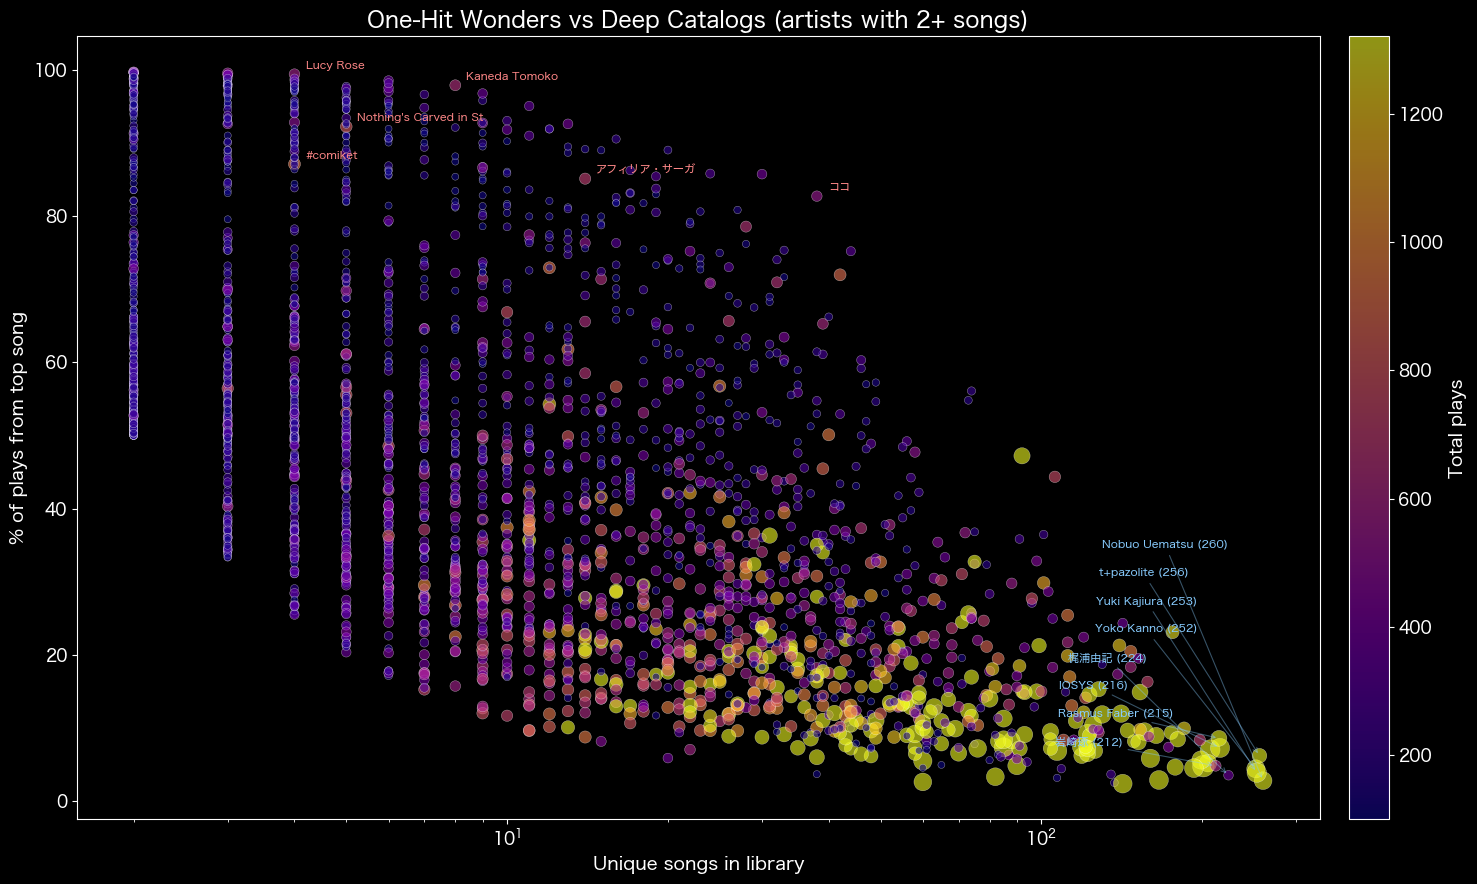

SINGLE-SONG ARTISTS with 100+ plays: 503 artists
(All at 100% concentration by definition — most-played shown)
    442×  REDLINE - Redline Day
    425×  Cynthia Harrell - Snake Eater
    361×  JAM Project feat. Hironobu Kageyama, Masaaki Endoh, Hiroshi Kitad
    361×  Shibayan feat. Yanagi Nagi - Fall In The Dark
    357×  Horie Yui, Tamura Yukari - Nano Desu
    324×  Yayoi Takatsuki (Mayako Nigo), Ritsuko Akituki (Naomi Wakabayashi
    317×  Hirose Koumi - Groovy!
    284×  Madeon x Monogatari - Slice The Snake
    278×  Higedriver feat. Kayano Ai, Harada Hitomi, Ogura Yui - Maware! Se
    278×  recog - Help me TOUMAAAAA!!

MOST CONCENTRATED multi-song artists (2+ songs, 100+ plays):
  Ally Kerr                        99.8%    2 songs  (436 plays)
  Minmi                            99.8%    2 songs  (423 plays)
  May'n and Nakajima Megumi        99.7%    2 songs  (341 plays)
  nothing                          99.7%    2 songs  (332 plays)
  Maaya Sakamoto & Steve Conte     99.7%    2

In [9]:
# Per artist: total plays, unique songs, top song plays, top song share
artist_songs = plays_clean.groupby(['artist', 'song']).size().reset_index(name='plays')
artist_stats = artist_songs.groupby('artist').agg(
    total_plays=('plays', 'sum'),
    n_songs=('song', 'nunique'),
    top_song_plays=('plays', 'max'),
).reset_index()
artist_stats['top_song_pct'] = artist_stats['top_song_plays'] / artist_stats['total_plays'] * 100
artist_stats['plays_per_song'] = artist_stats['total_plays'] / artist_stats['n_songs']

# Top song name
top_song_names = artist_songs.sort_values('plays', ascending=False).groupby('artist').first().reset_index()
artist_stats = artist_stats.merge(top_song_names[['artist', 'song']], on='artist', suffixes=('', '_top'))
artist_stats = artist_stats.rename(columns={'song': 'top_song'})

JUNK_ARTISTS = {'Various Artists', 'Various', 'VA', 'OST', 'Unknown'}
notable = artist_stats[(artist_stats['total_plays'] >= 100) &
                       (~artist_stats['artist'].isin(JUNK_ARTISTS))].copy()

# Split into two zones for clarity:
# Zone A: artists with 2+ songs (the interesting scatter)
# Zone B: single-song artists at 100% (just list them)
multi_song = notable[notable['n_songs'] >= 2].copy()
single_song = notable[notable['n_songs'] == 1].copy()

fig, ax = plt.subplots(figsize=(16, 9))
scatter = ax.scatter(multi_song['n_songs'], multi_song['top_song_pct'],
                     s=np.sqrt(multi_song['total_plays']) * 2.5,
                     c=multi_song['total_plays'], cmap='plasma',
                     alpha=0.6, edgecolors='white', linewidth=0.3,
                     norm=plt.Normalize(vmin=100, vmax=multi_song['total_plays'].quantile(0.95)))

# Label interesting points: high concentration (>80%) with many plays
high_conc = multi_song[(multi_song['top_song_pct'] > 80) & (multi_song['total_plays'] > 200)]
for _, r in high_conc.nlargest(6, 'total_plays').iterrows():
    ax.annotate(r['artist'][:22], (r['n_songs'], r['top_song_pct']),
                fontsize=8, color='#ff8888', xytext=(8, 4), textcoords='offset points')

# Label deep catalogs — place labels to the LEFT of points (away from colorbar)
deep = multi_song.nlargest(8, 'n_songs')
# Sort by n_songs descending, stagger vertically
deep_sorted = deep.sort_values('n_songs', ascending=False)
y_positions = np.linspace(35, 8, len(deep_sorted))
for i, (_, r) in enumerate(deep_sorted.iterrows()):
    ax.annotate(
        f'{r["artist"][:20]} ({r["n_songs"]})',
        xy=(r['n_songs'], r['top_song_pct']),
        xytext=(r['n_songs'] * 0.5, y_positions[i]),
        fontsize=8, color='#88ccff',
        arrowprops=dict(arrowstyle='->', color='#88ccff', alpha=0.4, lw=0.8),
        va='center',
    )

ax.set_xlabel('Unique songs in library')
ax.set_ylabel('% of plays from top song')
ax.set_title('One-Hit Wonders vs Deep Catalogs (artists with 2+ songs)')
ax.set_xscale('log')
plt.colorbar(scatter, label='Total plays', ax=ax, pad=0.02)
plt.tight_layout()
plt.show()

# Text tables — much cleaner for the extremes
print(f'SINGLE-SONG ARTISTS with 100+ plays: {len(single_song)} artists')
print(f'(All at 100% concentration by definition — most-played shown)')
for _, r in single_song.nlargest(10, 'total_plays').iterrows():
    print(f'  {r["total_plays"]:5,}×  {r["top_song"][:65]}')

print(f'\nMOST CONCENTRATED multi-song artists (2+ songs, 100+ plays):')
for _, r in multi_song.nlargest(10, 'top_song_pct').iterrows():
    print(f'  {r["artist"][:30]:30s}  {r["top_song_pct"]:5.1f}%  {r["n_songs"]:3d} songs  ({r["total_plays"]:,} plays)')

print(f'\nDEEPEST CATALOGS:')
for _, r in notable.nlargest(10, 'n_songs').iterrows():
    print(f'  {r["artist"][:30]:30s}  {r["n_songs"]:4d} songs  top song only {r["top_song_pct"]:.1f}%  ({r["total_plays"]:,} plays)')

---
## 8. Innovation Rate
_New songs per month over time._

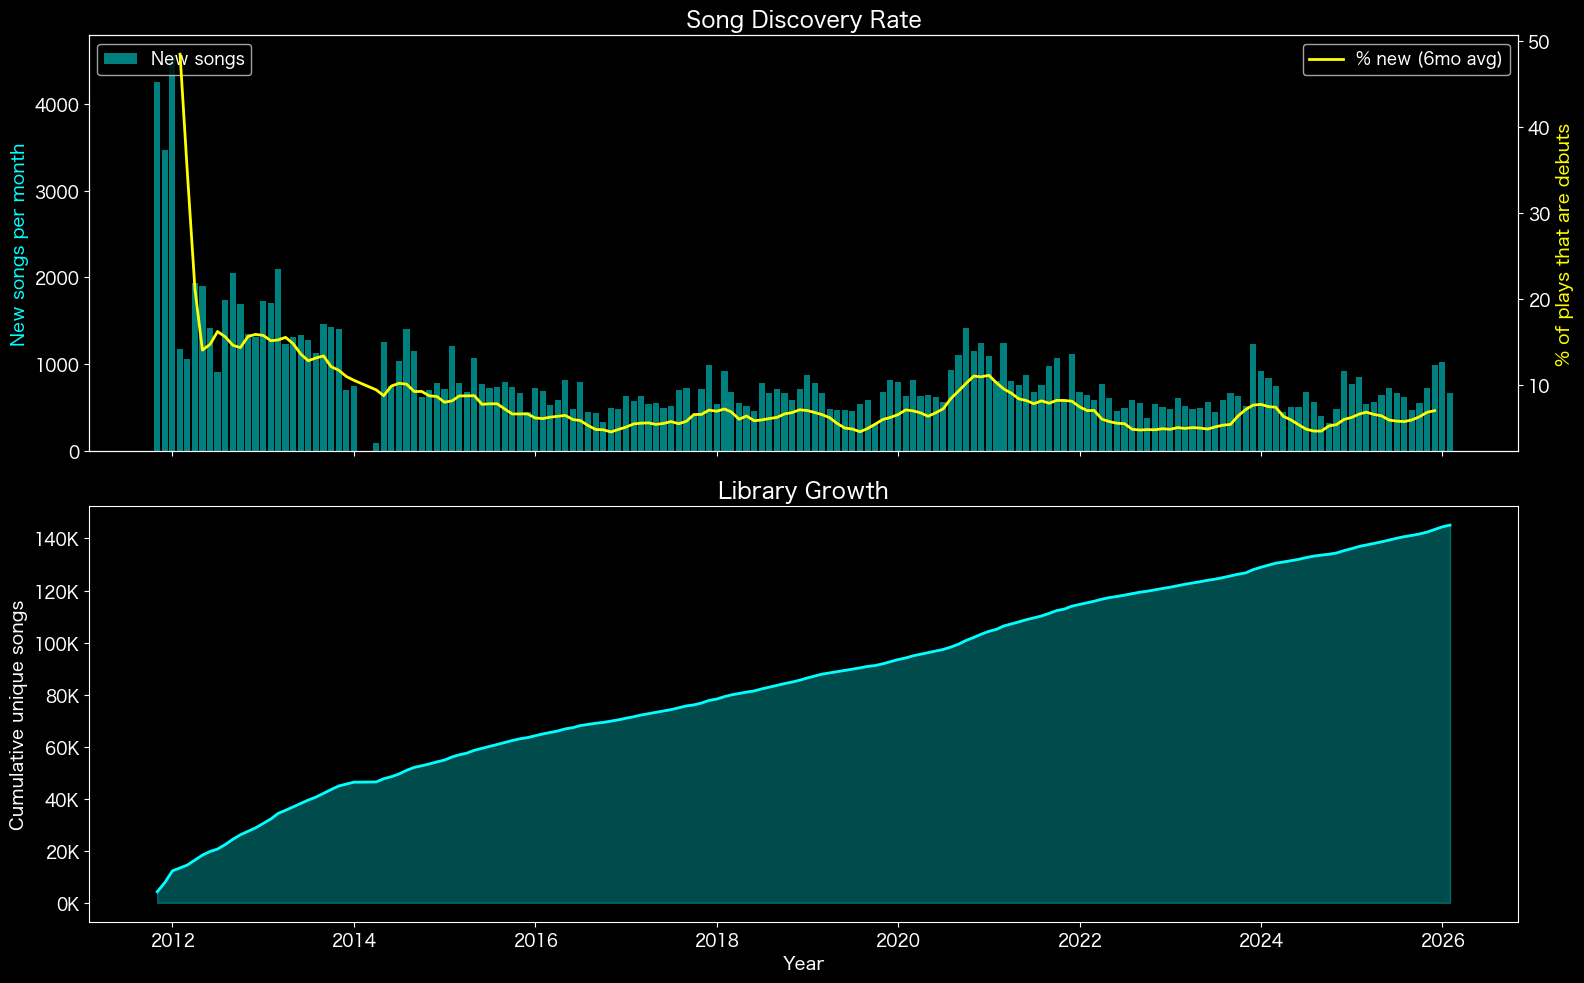

Innovation by era:
           avg_new_per_month  avg_new_pct  total_new
era                                                 
2011-2014             1504.2         18.6      54152
2015-2018              654.0          6.5      31391
2019-2022              734.1          7.1      35236
2023-2026              640.9          6.2      24355


In [10]:
# Per month: total plays, unique songs played, brand-new songs (first ever play)
plays_clean["ym"] = plays_clean["timestamp"].dt.to_period("M")
song_debut_ts = plays_clean.groupby("song")["timestamp"].min().rename("debut_ts")
plays_inn = plays_clean.merge(song_debut_ts, on="song")
plays_inn["is_debut"] = plays_inn["timestamp"] == plays_inn["debut_ts"]

monthly = (
    plays_inn.groupby("ym")
    .agg(
        total_plays=("song", "count"),
        unique_songs=("song", "nunique"),
        new_songs=("is_debut", "sum"),
    )
    .reset_index()
)
monthly["new_pct"] = monthly["new_songs"] / monthly["total_plays"] * 100
monthly["date"] = monthly["ym"].dt.to_timestamp()

# Cumulative library size
monthly["cum_library"] = monthly["new_songs"].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top: new songs per month + % new
ax1b = ax1.twinx()
ax1.bar(
    monthly["date"],
    monthly["new_songs"],
    width=25,
    color="cyan",
    alpha=0.5,
    label="New songs",
)
ax1b.plot(
    monthly["date"],
    monthly["new_pct"].rolling(6, center=True).mean(),
    color="yellow",
    linewidth=2,
    label="% new (6mo avg)",
)
ax1.set_ylabel("New songs per month", color="cyan")
ax1b.set_ylabel("% of plays that are debuts", color="yellow")
ax1.set_title("Song Discovery Rate")
ax1.legend(loc="upper left")
ax1b.legend(loc="upper right")

# Bottom: cumulative library
ax2.fill_between(monthly["date"], monthly["cum_library"], alpha=0.3, color="cyan")
ax2.plot(monthly["date"], monthly["cum_library"], color="cyan", linewidth=2)
ax2.set_ylabel("Cumulative unique songs")
ax2.set_xlabel("Year")
ax2.set_title("Library Growth")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1000:.0f}K"))

for ax in [ax1, ax2]:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

# Summary by era
monthly["era"] = pd.cut(
    monthly["date"].dt.year,
    bins=[2010, 2014, 2018, 2022, 2027],
    labels=["2011-2014", "2015-2018", "2019-2022", "2023-2026"],
)
era_summary = (
    monthly.groupby("era")
    .agg(
        avg_new_per_month=("new_songs", "mean"),
        avg_new_pct=("new_pct", "mean"),
        total_new=("new_songs", "sum"),
    )
    .round(1)
)
print("Innovation by era:")
print(era_summary.to_string())

---
## 9. Repetitiveness Over Time
_Shannon entropy of the monthly playlist._

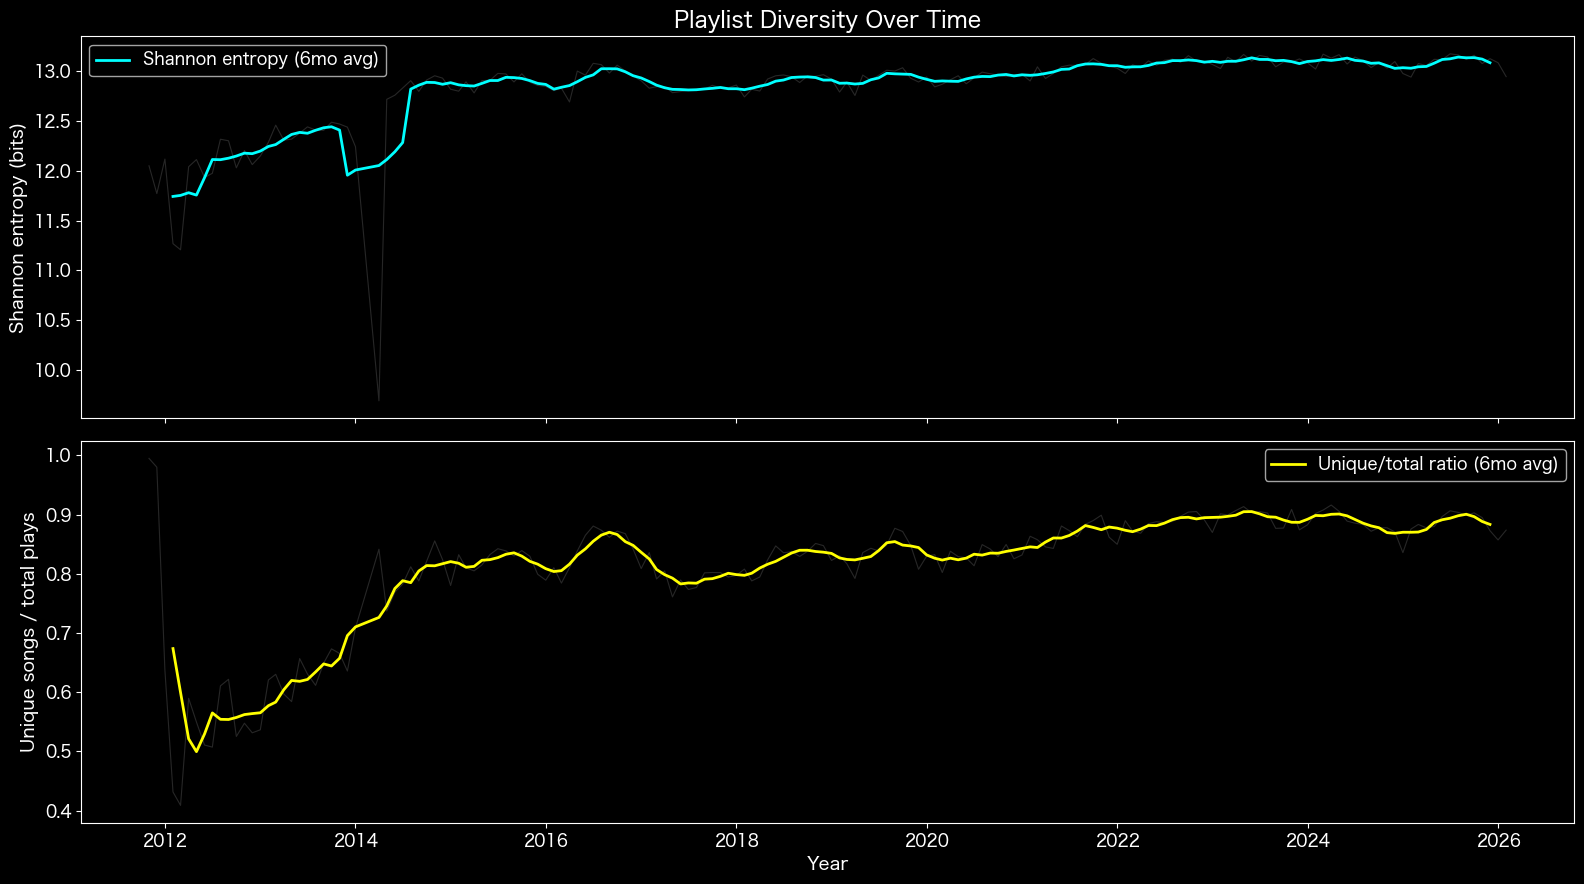

Average Shannon entropy:
  2013-2016: 12.68 bits
  2020-now:  13.06 bits
  Change:    +3.0%


In [11]:
from scipy.stats import entropy


# Monthly Shannon entropy (base 2) of song distribution
def monthly_entropy(group):
    counts = group["song"].value_counts()
    probs = counts / counts.sum()
    return entropy(probs, base=2)


monthly_ent = (
    plays_clean.groupby("ym").apply(monthly_entropy).rename("entropy").reset_index()
)
monthly_ent["date"] = monthly_ent["ym"].dt.to_timestamp()

# Also: unique songs / total plays ratio (simple diversity)
monthly_div = (
    plays_clean.groupby("ym")
    .agg(
        unique=("song", "nunique"),
        total=("song", "count"),
    )
    .reset_index()
)
monthly_div["diversity"] = monthly_div["unique"] / monthly_div["total"]
monthly_div["date"] = monthly_div["ym"].dt.to_timestamp()

# Max possible entropy = log2(unique songs that month)
monthly_ent = monthly_ent.merge(monthly_div[["ym", "unique", "total"]], on="ym")
monthly_ent["max_entropy"] = np.log2(monthly_ent["unique"])
monthly_ent["normalized_entropy"] = monthly_ent["entropy"] / monthly_ent["max_entropy"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Shannon entropy
ax1.plot(
    monthly_ent["date"], monthly_ent["entropy"], color="gray", alpha=0.3, linewidth=0.8
)
ax1.plot(
    monthly_ent["date"],
    monthly_ent["entropy"].rolling(6, center=True).mean(),
    color="cyan",
    linewidth=2,
    label="Shannon entropy (6mo avg)",
)
ax1.set_ylabel("Shannon entropy (bits)")
ax1.set_title("Playlist Diversity Over Time")
ax1.legend()

# Normalized entropy (0 = one song on repeat, 1 = perfectly uniform)
ax2.plot(
    monthly_div["date"],
    monthly_div["diversity"],
    color="gray",
    alpha=0.3,
    linewidth=0.8,
)
ax2.plot(
    monthly_div["date"],
    monthly_div["diversity"].rolling(6, center=True).mean(),
    color="yellow",
    linewidth=2,
    label="Unique/total ratio (6mo avg)",
)
ax2.set_ylabel("Unique songs / total plays")
ax2.set_xlabel("Year")
ax2.legend()

for ax in [ax1, ax2]:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

# Trend analysis
recent = monthly_ent[monthly_ent["date"].dt.year >= 2020]
early = monthly_ent[
    (monthly_ent["date"].dt.year >= 2013) & (monthly_ent["date"].dt.year <= 2016)
]
print(f"Average Shannon entropy:")
print(f"  2013-2016: {early['entropy'].mean():.2f} bits")
print(f"  2020-now:  {recent['entropy'].mean():.2f} bits")
print(
    f"  Change:    {(recent['entropy'].mean() - early['entropy'].mean()) / early['entropy'].mean() * 100:+.1f}%"
)

---
## 10. Fastest to 100 Plays


Bootstrap (2011-2013):
    Days  Year  DJs   Total  Song
  ──────  ────  ───  ──────  ────────────────────────────────────────────────────────────
      65  2012   16     513  Sporty-O feat. Akemi Homura - I want my UNTZ back
      85  2012   16     494  supercell - My Dearest
      97  2011    3     246  Megurine Luka - Just be friends
     107  2011   20     672  Seira Kagami - Super Special 
     125  2012    6     412  nayuta - 緋色月下、狂咲ノ絶 -1st Anniversary Remix-
     138  2012    4     444  Boku no Pico - Don't Listen to a Hardstyle song called -BOKU
     142  2012   40   1,410  FLOW - COLORS
     169  2012    3     433  ShibayanRecords feat. 3L - MyonMyonMyonMyonMyon!

Growth (2014-2017):
    Days  Year  DJs   Total  Song
  ──────  ────  ───  ──────  ────────────────────────────────────────────────────────────
     213  2017   19     185  どうぶつビスケッツ×PPP - ようこそジャパリパークへ
     463  2014   25     567  Lucy Rose - Shiver
     519  2014   19     363  Triple-Q - Walk the Dinozaki
     536 

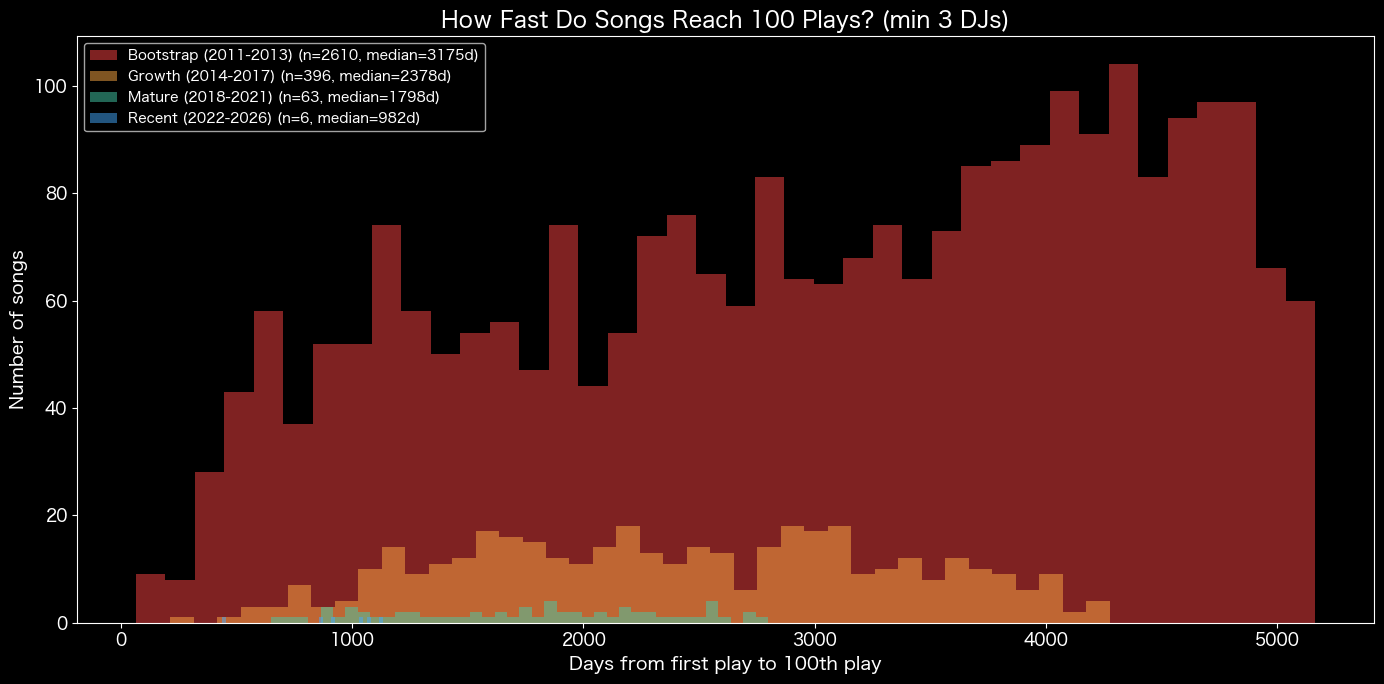


SLOWEST BURNERS (longest to reach 100 plays):
  14.1 years  (2011)  Chata - min～眠～
  14.1 years  (2011)  LOUDNESS - The Eternal Soldiers
  14.1 years  (2012)  Ikue Asazaki - Obokuri-eeumi
  14.1 years  (2012)  Mami Kawada - Prophecy
  14.1 years  (2011)  Faylan - Errand
  14.1 years  (2011)  Oogame Asuka - Kotatsu Kara Nagameru Sekai Chizu
  14.1 years  (2012)  Robbie Danzie - And Forever
  14.1 years  (2012)  Crystal King - Lupin the Third's Theme
  14.1 years  (2012)  Mizutsuki Ryo - TORCH
  14.1 years  (2012)  Typhoon24 - Spice of Life


In [12]:
# For songs with 100+ plays, find how many days from first play to 100th play
# Exclude single-DJ spam: require at least 3 different DJs played the song
song_dj_count = plays_clean.groupby('song')['dj'].nunique().rename('n_djs')
popular_songs = song_life[song_life['total_plays'] >= 100]['song'].values

velocity_data = []
for song in popular_songs:
    n_djs = song_dj_count.get(song, 0)
    if n_djs < 3:
        continue
    song_plays = plays_clean[plays_clean['song'] == song].sort_values('timestamp')
    if len(song_plays) >= 100:
        first = song_plays.iloc[0]['timestamp']
        hundredth = song_plays.iloc[99]['timestamp']
        days_to_100 = (hundredth - first).days
        velocity_data.append({
            'song': song,
            'days_to_100': days_to_100,
            'total_plays': len(song_plays),
            'debut_year': first.year,
            'artist': song_plays.iloc[0]['artist'],
            'n_djs': n_djs,
        })

vel = pd.DataFrame(velocity_data).sort_values('days_to_100')

# Show fastest per era
era_bins = [(2011, 2013, 'Bootstrap (2011-2013)'),
            (2014, 2017, 'Growth (2014-2017)'),
            (2018, 2021, 'Mature (2018-2021)'),
            (2022, 2026, 'Recent (2022-2026)')]

for y1, y2, era_name in era_bins:
    era_vel = vel[(vel['debut_year'] >= y1) & (vel['debut_year'] <= y2)].head(8)
    if len(era_vel) == 0:
        continue
    print(f'\n{era_name}:')
    print(f'  {"Days":>6s}  {"Year":>4s}  {"DJs":>3s}  {"Total":>6s}  Song')
    print(f'  {"─"*6}  {"─"*4}  {"─"*3}  {"─"*6}  {"─"*60}')
    for _, r in era_vel.iterrows():
        print(f'  {r["days_to_100"]:6d}  {r["debut_year"]:4d}  {r["n_djs"]:3.0f}  {r["total_plays"]:6,}  {r["song"][:60]}')

# Distribution by era
fig, ax = plt.subplots(figsize=(14, 7))
colors_era = ['#ff4444', '#ffaa44', '#44ccaa', '#44aaff']
for (y1, y2, label), color in zip(era_bins, colors_era):
    era_vel = vel[(vel['debut_year'] >= y1) & (vel['debut_year'] <= y2)]
    if len(era_vel) > 0:
        ax.hist(era_vel['days_to_100'], bins=40, color=color, alpha=0.5,
                label=f'{label} (n={len(era_vel)}, median={era_vel["days_to_100"].median():.0f}d)',
                edgecolor='none')

ax.set_xlabel('Days from first play to 100th play')
ax.set_ylabel('Number of songs')
ax.set_title('How Fast Do Songs Reach 100 Plays? (min 3 DJs)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'\nSLOWEST BURNERS (longest to reach 100 plays):')
for _, r in vel.tail(10).iloc[::-1].iterrows():
    yrs = r['days_to_100'] / 365.25
    print(f'  {yrs:.1f} years  ({r["debut_year"]})  {r["song"][:60]}')

---
## 11. Seasonal Songs

MOST SEASONAL SONGS (50+ plays, 3+ DJs, sorted by month):
  25% in Jan    59×  m-flo loves Adee A. - Reckless
  38% in Jan    60×  Matsudaira Ken - Matsuken Samba II
  22% in Jan    51×  Kilim - banjos

  63% in Mar    59×  Nyanners - POMFPOMFPOMF =3
  30% in Mar    50×  765Pro Allstars - Ready!!
  27% in Mar    86×  きゃりーとけいとけい - SMOKESMOKESMOKE
  24% in Mar   115×  ろん & Gero - PONPONPON

  16% in Jun    50×  Nyarons - Chameleon
  18% in Jun    67×  (K)NoW_NAME - rainy tone

  30% in Oct    56×  ちよこ - Alice's Mad Tea Party

  21% in Nov    61×  #18 JUHACHI-BANG - 昨日の虹

  36% in Dec    83×  DAVE RODGERS - ALL I WANT FOR CHRISTMAS IS YOU
  18% in Dec    50×  栗林みな実、橋本みゆき、飛蘭、美郷あき、yozuca*、rino - すーぱー☆あふぇくしょん
  19% in Dec    52×  Joman - Daymanstep
  25% in Dec    57×  Taishi feat. cumlord - Beyond the Cum Zone
  30% in Dec   155×  Hisakawa Aya - Jingle Bells
  31% in Dec   113×  Ito Chieri - Merry Christmas
  24% in Dec    55×  Twin Tales - Twin Tails Dreamer
  28% in Dec    86×  ROUND TABL

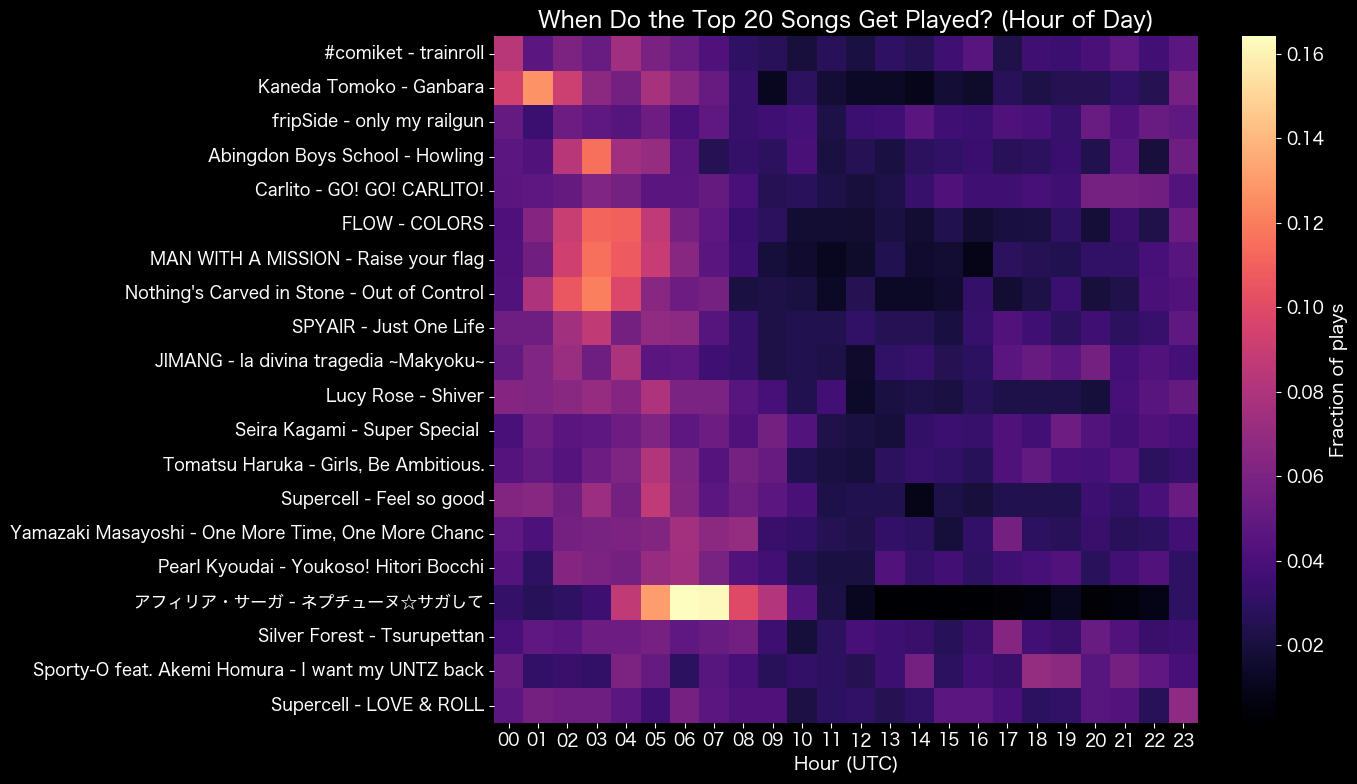

In [13]:
# Seasonal concentration: for songs with 50+ plays, played by 3+ DJs
from scipy.stats import entropy as sp_entropy

songs_50plus = song_life[song_life['total_plays'] >= 50]['song'].values
multi_dj = plays_clean.groupby('song')['dj'].nunique()
multi_dj_songs = set(multi_dj[multi_dj >= 3].index)
seasonal_plays = plays_clean[plays_clean['song'].isin(songs_50plus) &
                              plays_clean['song'].isin(multi_dj_songs)].copy()

def month_concentration(group):
    month_counts = group['month'].value_counts()
    probs = month_counts / month_counts.sum()
    ent = sp_entropy(probs, base=2)
    max_ent = np.log2(12)
    peak_month = month_counts.idxmax()
    peak_pct = month_counts.max() / month_counts.sum()
    return pd.Series({
        'month_entropy': ent,
        'month_concentration': 1 - ent / max_ent,
        'peak_month': peak_month,
        'peak_month_pct': peak_pct,
    })

seasonal = seasonal_plays.groupby('song').apply(month_concentration).reset_index()
seasonal = seasonal.merge(song_life[['song', 'total_plays', 'artist']], on='song')

most_seasonal = seasonal.sort_values('month_concentration', ascending=False).head(20)
# Sort by peak month, then by concentration within month
most_seasonal = most_seasonal.sort_values(['peak_month', 'month_concentration'],
                                           ascending=[True, False])

month_names = ['', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print('MOST SEASONAL SONGS (50+ plays, 3+ DJs, sorted by month):')
prev_month = None
for _, r in most_seasonal.iterrows():
    m = month_names[int(r['peak_month'])]
    if prev_month is not None and int(r['peak_month']) != prev_month:
        print()  # blank line between months
    prev_month = int(r['peak_month'])
    print(f'  {r["peak_month_pct"]:.0%} in {m:3s}  {r["total_plays"]:4.0f}×  {r["song"][:60]}')

# Hour-of-day heatmap for top 20 songs (also require multi-DJ)
top20_songs = [s for s in song_counts['song'].values if s in multi_dj_songs][:20]
hourly = plays_clean[plays_clean['song'].isin(top20_songs)].groupby(['song', 'hour']).size().reset_index(name='plays')
hourly_pivot = hourly.pivot_table(index='song', columns='hour', values='plays', fill_value=0)
hourly_pct = hourly_pivot.div(hourly_pivot.sum(axis=1), axis=0)

hourly_pct['peak_hour'] = hourly_pct.idxmax(axis=1)
hourly_pct = hourly_pct.sort_values('peak_hour')
hourly_pct = hourly_pct.drop(columns='peak_hour')

short_names = [s[:50] for s in hourly_pct.index]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(hourly_pct, cmap='magma', ax=ax,
            yticklabels=short_names, xticklabels=[f'{h:02d}' for h in range(24)],
            cbar_kws={'label': 'Fraction of plays'})
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('')
ax.set_title('When Do the Top 20 Songs Get Played? (Hour of Day)')
plt.tight_layout()
plt.show()

---
## 12. Title Keywords

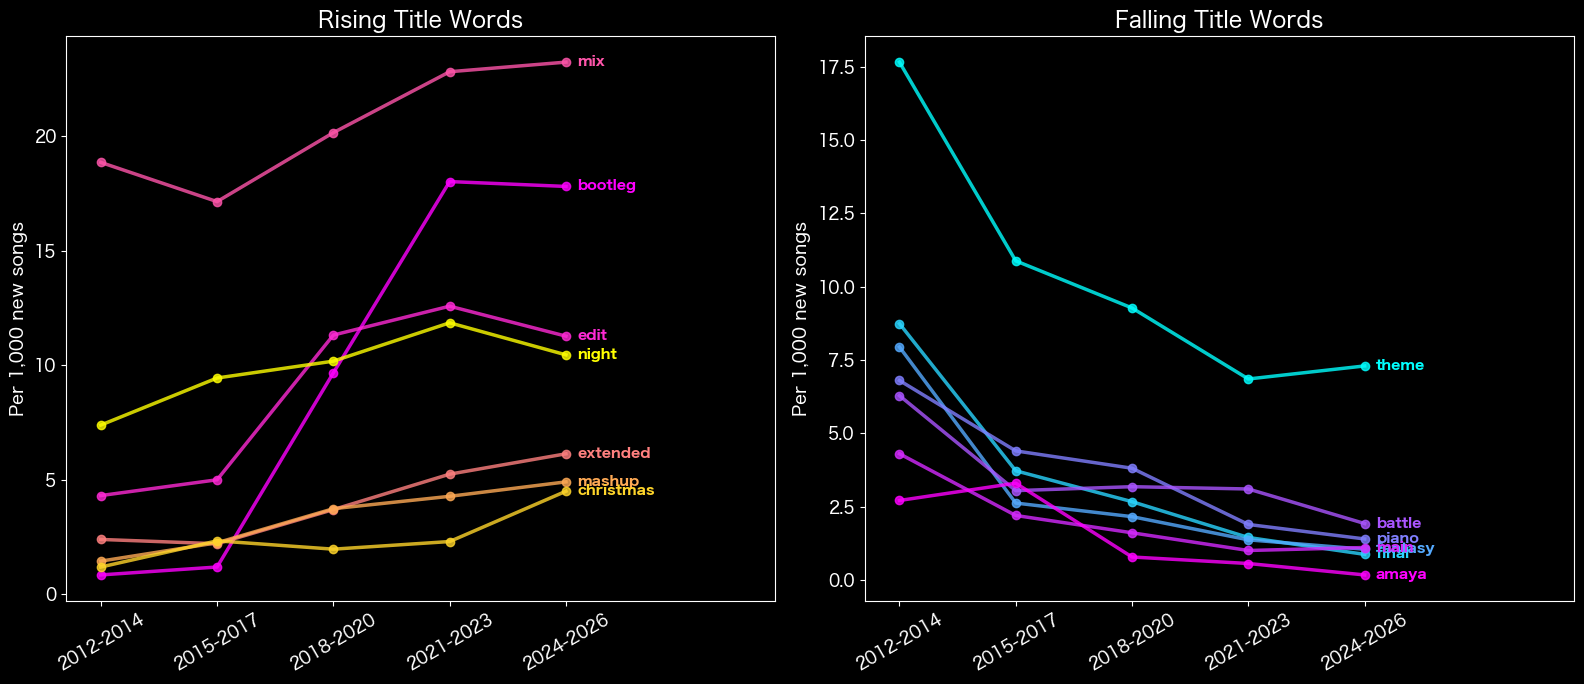

All-time top 20 title words:
   2758  mix
   2206  love
   1608  theme
   1298  night
   1166  world
   1111  edit
   1065  bootleg
    999  your
    964  song
    923  time
    841  girl
    770  one
    710  moon
    703  heart
    679  blue
    667  life
    666  dream
    613  final
    606  star
    600  sky


In [14]:
import re
from collections import Counter

song_debut_year = song_life[['song', 'debut_year', 'total_plays']].copy()
song_debut_year['title'] = song_debut_year['song'].apply(
    lambda s: s.split(' - ', 1)[1] if ' - ' in s else s
)

stop = {'the', 'a', 'an', 'of', 'in', 'to', 'for', 'and', 'or', 'is', 'it',
        'my', 'no', 'on', 'at', 'by', 'from', 'with', 'ver', 'feat', 'ft',
        'remix', 'version', 'op', 'ed', 'tv', 'size', 'full', 'short',
        'i', 'you', 'me', 'we', 'he', 'she', 'de', 'wa', 'wo', 'ni', 'ga',
        'na', 'ka'}

def extract_words(title):
    words = re.findall(r'[a-zA-Z]{3,}', title.lower())
    return [w for w in words if w not in stop]

eras = [(2012, 2014), (2015, 2017), (2018, 2020), (2021, 2023), (2024, 2026)]
era_words = {}
for y1, y2 in eras:
    era_songs = song_debut_year[(song_debut_year['debut_year'] >= y1) & (song_debut_year['debut_year'] <= y2)]
    words = []
    for title in era_songs['title']:
        words.extend(extract_words(title))
    era_words[f'{y1}-{y2}'] = Counter(words)

all_era_keys = list(era_words.keys())
all_words = set()
for c in era_words.values():
    all_words.update(c.keys())

era_sizes = {}
for y1, y2 in eras:
    era_sizes[f'{y1}-{y2}'] = len(song_debut_year[(song_debut_year['debut_year'] >= y1) & (song_debut_year['debut_year'] <= y2)])

word_trends = []
for w in all_words:
    row = {'word': w}
    for era_key in all_era_keys:
        row[era_key] = era_words[era_key].get(w, 0) / era_sizes[era_key] * 1000
    row['trend'] = row[all_era_keys[-1]] - row[all_era_keys[0]]
    row['total'] = sum(era_words[ek].get(w, 0) for ek in all_era_keys)
    word_trends.append(row)

wt = pd.DataFrame(word_trends)
wt = wt[wt['total'] >= 30]

rising = wt.nlargest(7, 'trend')
falling = wt.nsmallest(7, 'trend')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

cmap_r = plt.cm.spring
cmap_f = plt.cm.cool

# Rising — label at the right end
for i, (_, r) in enumerate(rising.iterrows()):
    color = cmap_r(i / max(len(rising) - 1, 1))
    vals = [r[ek] for ek in all_era_keys]
    ax1.plot(range(len(eras)), vals, marker='o', alpha=0.8, linewidth=2.5, color=color)
    ax1.annotate(r['word'], (len(eras) - 1, vals[-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=10, fontweight='bold', color=color,
                va='center', ha='left')

ax1.set_xticks(range(len(eras)))
ax1.set_xticklabels(all_era_keys, rotation=30)
ax1.set_ylabel('Per 1,000 new songs')
ax1.set_title('Rising Title Words')
ax1.set_xlim(-0.3, len(eras) + 0.8)

# Falling — ALSO label at the right end (where lines converge = more room)
for i, (_, r) in enumerate(falling.iterrows()):
    color = cmap_f(i / max(len(falling) - 1, 1))
    vals = [r[ek] for ek in all_era_keys]
    ax2.plot(range(len(eras)), vals, marker='o', alpha=0.8, linewidth=2.5, color=color)
    ax2.annotate(r['word'], (len(eras) - 1, vals[-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=10, fontweight='bold', color=color,
                va='center', ha='left')

ax2.set_xticks(range(len(eras)))
ax2.set_xticklabels(all_era_keys, rotation=30)
ax2.set_ylabel('Per 1,000 new songs')
ax2.set_title('Falling Title Words')
ax2.set_xlim(-0.3, len(eras) + 0.8)

plt.tight_layout()
plt.show()

all_time = Counter()
for c in era_words.values():
    all_time.update(c)
print('All-time top 20 title words:')
for word, count in all_time.most_common(20):
    print(f'  {count:5d}  {word}')